In [1]:
#!pip install transformers datasets huggingface_hub

Due to the lack of running time, I will shrink my dataset to only 10 picutres in the first 10 subfolders. Which means I will have in total 1000 pictures of 100 landmarks.

# Data Processing

In [2]:
import os
import shutil
from pathlib import Path

# Root directory containing all subfolders
root_dir = '/kaggle/input/qudata-gembed-landmarks-210/landmarks'
# Directory to save the modified dataset
output_dir = '/kaggle/working/modified'

# Create the output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Get the list of subfolders, sorted for consistent result when repeating
subfolders = sorted([f.path for f in os.scandir(root_dir) if f.is_dir()])

# Limit to the first 100 subfolders for computational convenience
selected_subfolders = subfolders[:100]

# Process each selected subfolder
for subfolder in selected_subfolders:
    # Create corresponding subfolder in the output directory
    subfolder_name = os.path.basename(subfolder)
    new_subfolder_path = os.path.join(output_dir, subfolder_name)
    os.makedirs(new_subfolder_path, exist_ok=True)
    
    # Get the list of images in the subfolder
    images = sorted([f for f in os.listdir(subfolder) if f.lower().endswith(('png', 'jpg', 'jpeg'))])
    
    # Select up to 10 images
    selected_images = images[:10]  
    
    # Copy the selected images to the new subfolder
    for image in selected_images:
        src_path = os.path.join(subfolder, image)
        dest_path = os.path.join(new_subfolder_path, image)
        shutil.copy(src_path, dest_path)

print("Dataset minimization complete.")


Dataset minimization complete.


In [3]:
#split the dataset into training and testing sets
import datasets
import os
import random
from sklearn.model_selection import train_test_split

def split_dataset(root_dir, test_size=0.2, random_seed=42):

    train_data = []
    test_data = []
    random.seed(random_seed)

    for label in os.listdir(root_dir):
        label_path = os.path.join(root_dir, label)
        if os.path.isdir(label_path):
            images = [os.path.join(label_path, img) for img in os.listdir(label_path)]
            train_imgs, test_imgs = train_test_split(images, test_size=test_size, random_state=random_seed)
            train_data.extend([(img, label) for img in train_imgs])
            test_data.extend([(img, label) for img in test_imgs])
    
    return train_data, test_data


In [4]:
root_dir = output_dir
train_data, test_data = split_dataset(root_dir)

# Model set-up

In [5]:
from PIL import Image
from torch.utils.data import Dataset
from transformers import AutoProcessor, BlipForConditionalGeneration

save_path = "/kaggle/input/blip-base/my_huggingface_model"

processor = AutoProcessor.from_pretrained(save_path)
model = BlipForConditionalGeneration.from_pretrained(save_path)

In [6]:
#process the dataset for further usage
class LandmarkDataset(Dataset):
    def __init__(self, data, processor, transform=None):
        """
        Args:
            data (list): List of (image_path, label) tuples.
            processor (BLIPProcessor): Processor for BLIP.
            transform (callable, optional): Optional transform to be applied on an image.
        """
        self.data = data
        self.transform = transform
        self.processor = processor

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path, label = self.data[idx]
        image = Image.open(img_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)

        # Use processor to tokenize caption and process the image
        inputs = self.processor(images=image, text=label, return_tensors="pt", padding="max_length", truncation=True)

        return {
            "input_ids": inputs["input_ids"].squeeze(0),
            "pixel_values": inputs["pixel_values"].squeeze(0),
            "attention_mask": inputs["attention_mask"].squeeze(0),
            "labels": label
        }


In [7]:
from torch.utils.data import Dataset, DataLoader
# Create datasets
train_dataset = LandmarkDataset(data=train_data, processor=processor)
test_dataset = LandmarkDataset(data=test_data, processor=processor)

# Create DataLoaders
train_dataloader = DataLoader(train_dataset, batch_size=2, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=2, shuffle=False)


# Fine tune the model

In [8]:
import torch

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

model.train()

for epoch in range(5):
    print("Epoch:", epoch)
    for idx, batch in enumerate(train_dataloader):
        input_ids = batch.pop("input_ids").to(device)
        pixel_values = batch.pop("pixel_values").to(device)

        outputs = model(input_ids=input_ids,
                        pixel_values=pixel_values,
                        labels=input_ids)
        
        loss = outputs.loss

        print("Loss:", loss.item())

        loss.backward()

        optimizer.step()
        optimizer.zero_grad()

Epoch: 0


We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.


Loss: 13.186444282531738
Loss: 10.316598892211914
Loss: 10.201164245605469
Loss: 10.149191856384277
Loss: 10.18360710144043
Loss: 10.18511962890625
Loss: 10.184844017028809
Loss: 10.136849403381348
Loss: 10.107637405395508
Loss: 10.096051216125488
Loss: 10.018903732299805
Loss: 10.052597999572754
Loss: 9.723569869995117
Loss: 9.266667366027832
Loss: 9.2481689453125
Loss: 8.804757118225098
Loss: 8.6434326171875
Loss: 8.437978744506836
Loss: 8.278817176818848
Loss: 8.10578727722168
Loss: 7.911300182342529
Loss: 7.708131313323975
Loss: 7.553093910217285
Loss: 7.389460563659668
Loss: 7.257205963134766
Loss: 7.0914225578308105
Loss: 6.87918758392334
Loss: 6.804711818695068
Loss: 6.636962413787842
Loss: 6.488185405731201
Loss: 6.354748249053955
Loss: 6.213264465332031
Loss: 6.037622451782227
Loss: 5.858181953430176
Loss: 5.740173816680908
Loss: 5.566690921783447
Loss: 5.432238578796387
Loss: 5.2734880447387695
Loss: 5.135395050048828
Loss: 5.002370834350586
Loss: 4.840368270874023
Loss: 4.67

In [9]:
#save the model for further usage
model.save_pretrained("fine_tuned_landmark_model")
processor.save_pretrained("fine_tuned_landmark_model")

[]

# Test the model and display the result

In [10]:
#test the model by test_data

import matplotlib.pyplot as plt
from tqdm import tqdm
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()

# Generate captions for the test dataset
def generate_captions(test_data, processor, model, device):
    """
    Generates captions for the test dataset.

    Args:
        test_data (list): List of (image_path, label) tuples.
        processor (AutoProcessor): Processor for the model.
        model (BlipForConditionalGeneration): Fine-tuned model.
        device (str): Device for computation ('cuda' or 'cpu').

    Returns:
        results (list): List of dictionaries containing 'image', 'predicted_caption', and 'true_label'.
    """
    results = []
    
    for img_path, true_label in tqdm(test_data, desc="Generating captions"):
        # Load and process the image
        image = Image.open(img_path).convert("RGB")
        inputs = processor(images=image, return_tensors="pt").to(device)

        # Generate caption
        output_ids = model.generate(pixel_values=inputs["pixel_values"])
        predicted_caption = processor.decode(output_ids[0], skip_special_tokens=True)
        
        # Store the result
        results.append({
            "image": img_path,
            "predicted_caption": predicted_caption,
            "true_label": true_label
        })
    return results

# Run the testing
test_results = generate_captions(test_data, processor, model, device)


Generating captions:   0%|          | 0/200 [00:00<?, ?it/s]/opt/conda/lib/python3.10/site-packages/transformers/generation/utils.py:1375: UserWarning: Using the model-agnostic default `max_length` (=20) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(
Generating captions: 100%|██████████| 200/200 [00:47<00:00,  4.24it/s]


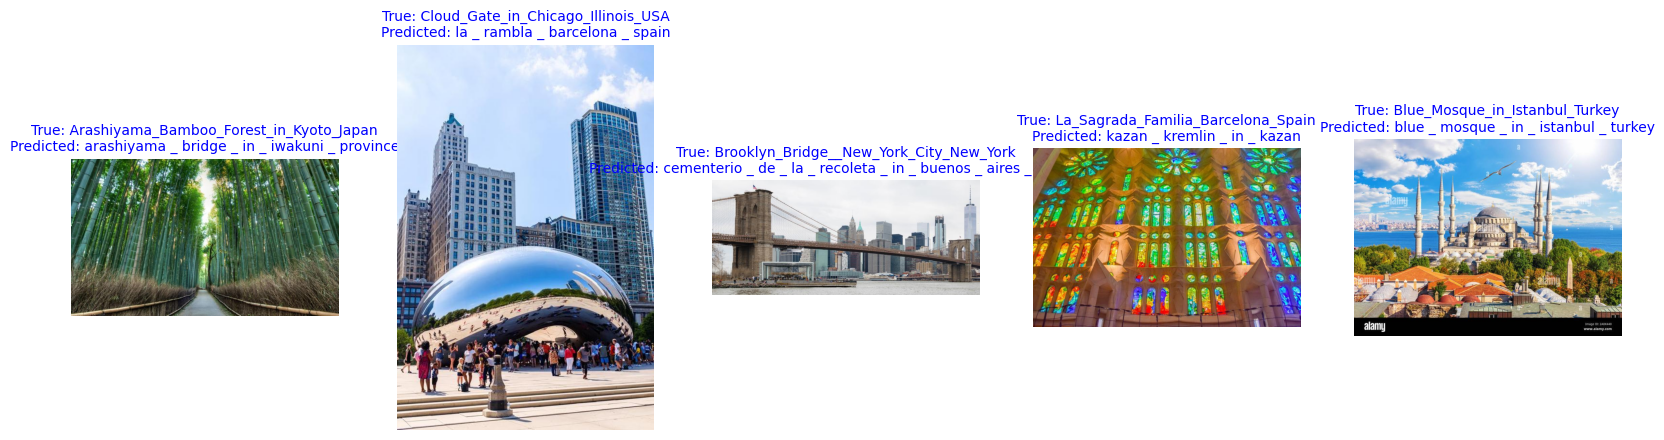

In [11]:
#plot the sample result
random.seed(42)
# Randomly select 5 samples from the test dataset
num_samples = 5
random_indices = random.sample(range(len(test_results)), num_samples)
random_samples = [test_results[idx] for idx in random_indices]

fig, axes = plt.subplots(1, num_samples, figsize=(20, 5))
for i, result in enumerate(random_samples):
    # Plot the image and annotate
    axes[i].imshow(Image.open(result['image']).convert("RGB"))
    axes[i].axis('off')
    axes[i].set_title(
        f"True: {result['true_label']}\nPredicted: {result['predicted_caption']}", 
        fontsize=10, color="blue", loc="center"
    )
plt.show()